In [1]:
using PyPlot
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful
using OrdinaryDiffEq

In [ ]:
# """ Derivative of the incident laser beam taking into account the absorption of the independant atoms for a gaussian density, but not the SE """
# function deriv_Iinc_no_SE(du, u, p, t)
#     N, σ, γ, Isat = p
#     du[1] = -N*γ*exp(-t^2/(2σ^2)) / (2*sqrt(2π)*Isat*(1 +1/u[1]))
# end

function deriv_Iinc_no_SE(du, u, p, t)
    N, σ, γ, Isat = p
    du[1] = -vertical_density(N, σ, t) * γ / (1 + 1/u[1])
end

""" Derivative of the incident laser beam taking into account the absorption of the independant atoms for a gaussian density, but not the SE """
function deriv_Iinc_no_SE_norm(du, u, p, t)
    N, σ, γ, Isat = p
    du[1] = -N*γ*σ*exp(-t^2/2) / (2*sqrt(2π)*Isat*(1 +1/u[1]))
end

function vertical_density(Nz, σ, z)
    return Nz*exp.(-z.^2 ./(2*σ^2)) / (sqrt(2π)*σ)
end

function vertical_density_norm(Nz, σ, z)
    return Nz*exp.(-z.^2 ./2) / (sqrt(2π)*σ)
end

vertical_density_norm (generic function with 1 method)

In [3]:
N_atoms_z = 100
ξz = 0.8e-6 # Vertical HO length, sqrt(ustrip(ħ)/(162.5*1.6e-27*2*π* 98))
γ = 32.7e6 # In Hz
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ
sat = [0:100;]
Isat = ustrip(ħ)*γ*ω0^3 / (12π*ustrip(c_0)^2);

In [12]:
sum(vertical_density(N_atoms_z, ξz, z_range).*ξz/100)

99.99994414401628

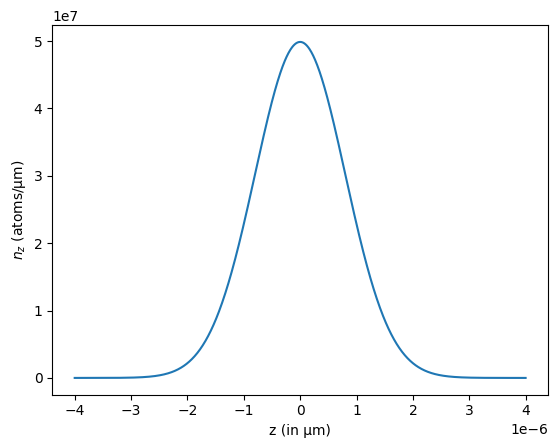

In [14]:
close("all")
fig = subplots()

z_range = [-5*ξz:ξz/100:5*ξz;]
plot(z_range, vertical_density(N_atoms_z, ξz, z_range))
# plot(z_range*1e6, vertical_density(N_atoms_z, ξz, z_range)*1e-6)
xlabel("z (in μm)")
ylabel(L"$n_z$ (atoms/μm)")

pygui(false); gcf()

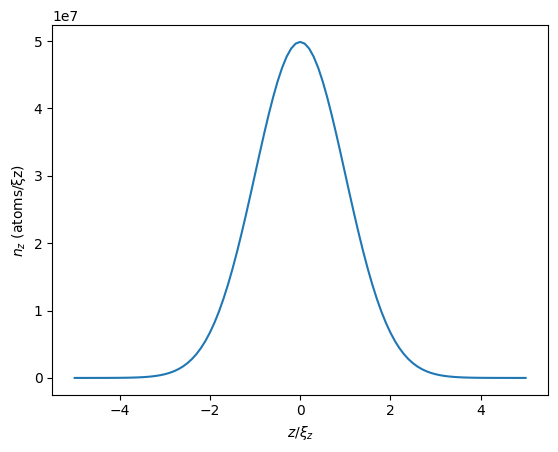

In [5]:
close("all")
fig = subplots()

z_range_norm = [-5:0.1:5;] # In units of ξz

plot(z_range_norm, vertical_density_norm(N_atoms_z, ξz, z_range_norm))
xlabel(L"$z/\xi_z$")
ylabel(L"$n_z$ (atoms/ξz)")

pygui(false); gcf()

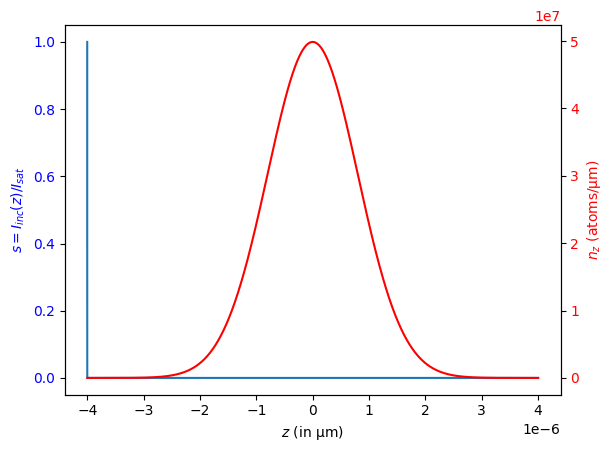

In [6]:
u0 = [sat[2]]
p = [N_atoms_z, ξz, γ, Isat]
z_range = [-5*ξz:ξz/100:5*ξz;]
prob = ODEProblem(deriv_Iinc_no_SE, u0, (z_range[1], z_range[end]), p)
sol = solve(prob, reltol = 1e-8, abstol = 1e-8);

close("all")
fig, ax = subplots()

ax.plot(sol.t, sol.u)
ax.set_ylabel(L"$s=I_{inc}(z)/I_{sat}$", color="b")
ax.tick_params(axis="y", labelcolor="b")

ax2 = ax.twinx()
ax2.plot(z_range, vertical_density(N_atoms_z, ξz, z_range), color="r")
ax2.set_ylabel(L"$n_z$ (atoms/μm)", color="r")
ax2.tick_params(axis="y", labelcolor="r")

ax.set_xlabel(L"$z$ (in μm)")

pygui(false); gcf()
# pygui(true); show()

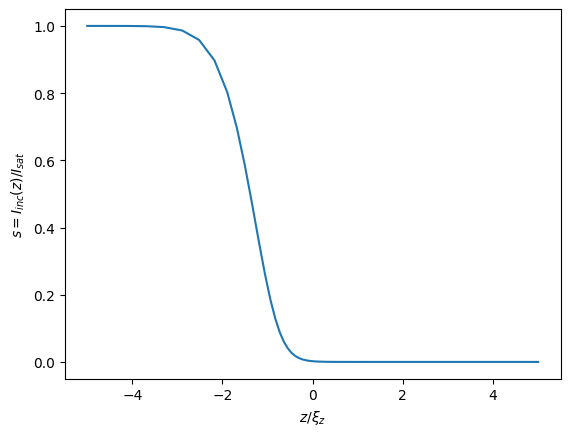

In [7]:
u0 = [sat[2]]
p = [N_atoms_z, ξz, γ, Isat]
prob = ODEProblem(deriv_Iinc_no_SE_norm, u0, (-5, 5), p)
sol = solve(prob, reltol = 1e-8, abstol = 1e-8);

close("all")
fig = subplots()

plot(sol.t, sol.u)
xlabel(L"$z/\xi_z$")
ylabel(L"$s=I_{inc}(z)/I_{sat}$")

pygui(false); gcf()
# pygui(true); show()

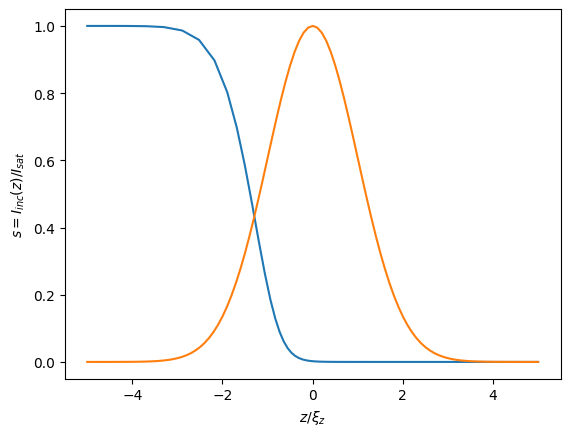

In [8]:
close("all")
fig = subplots()

plot(sol.t, sol.u)
xlabel(L"$z/\xi_z$")
ylabel(L"$s=I_{inc}(z)/I_{sat}$")

plot(z_range_norm, vertical_density_norm(N_atoms_z, ξz, z_range_norm)/maximum(vertical_density_norm(N_atoms_z, ξz, z_range_norm)))

pygui(false); gcf()
# pygui(true); show()